<a href="https://colab.research.google.com/github/Zarnigor05/AI-Couse-Electrical-and-Computer-dept/blob/main/speedprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Predicted speed at 17:00 (Parabolic): 43.65 km/h


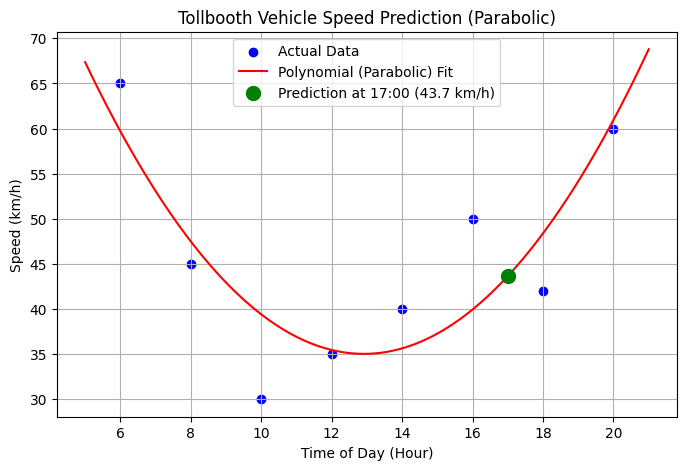

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 1. Ma'lumotlar (Vaqt va Tezlik)
X = np.array([6, 8, 10, 12, 14, 16, 18, 20]).reshape(-1, 1)  # Soatlar
y = np.array([65, 45, 30, 35, 40, 50, 42, 60])                 # Tezliklar

# 2. Parabolik xususiyatlarni qo'shish (degree=2 kvadratik egri chiziq uchun)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# 3. Modelni o'qitish
model = LinearRegression()
model.fit(X_poly, y)

# 4. Soat 17:00 (17.0) uchun tezlikni bashorat qilish
target_time = np.array([[17.0]])
target_time_poly = poly.transform(target_time)
predicted_speed = model.predict(target_time_poly)[0]

# 5. Bashorat qilingan tezlikni chop etish
print(f"Predicted speed at 17:00 (Parabolic): {predicted_speed:.2f} km/h")

# 6. Grafikda parabolik chiziqni ko'rsatish
X_range = np.linspace(5, 21, 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_range_pred = model.predict(X_range_poly)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X_range, y_range_pred, color='red', label='Polynomial (Parabolic) Fit')

# 17:00 dagi bashorat nuqtasini belgilash
plt.scatter(target_time, predicted_speed, color='green', s=100, zorder=5,
            label=f'Prediction at 17:00 ({predicted_speed:.1f} km/h)')

plt.title('Tollbooth Vehicle Speed Prediction (Parabolic)')
plt.xlabel('Time of Day (Hour)')
plt.ylabel('Speed (km/h)')
plt.legend()
plt.grid(True)
plt.show()